In [ ]:

import pandas as pd


df = pd.read_csv("/content/Crop_recommendation.csv")


df.head()

,N,P,K,temperature,humidity,ph,rainfall,label
0,90,42,43,20.879744,82.002744,6.502985,202.935536,rice
1,85,58,41,21.770462,80.319644,7.038096,226.655537,rice
2,60,55,44,23.004459,82.320763,7.840207,263.964248,rice
3,74,35,40,26.491096,80.158363,6.980401,242.864034,rice
4,78,42,42,20.130175,81.604873,7.628473,262.717340,rice


In [ ]:

df.info()


df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2200 entries, 0 to 2199
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   N            2200 non-null   int64  
 1   P            2200 non-null   int64  
 2   K            2200 non-null   int64  
 3   temperature  2200 non-null   float64
 4   humidity     2200 non-null   float64
 5   ph           2200 non-null   float64
 6   rainfall     2200 non-null   float64
 7   label        2200 non-null   object 
dtypes: float64(4), int64(3), object(1)
memory usage: 137.6+ KB


,0
N,0
P,0
K,0
temperature,0
humidity,0
ph,0
rainfall,0
label,0


In [ ]:

df.describe()

,N,P,K,temperature,humidity,ph,rainfall
count,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000,2200.000000
mean,50.551818,53.362727,48.149091,25.616244,71.481779,6.469480,103.463655
std,36.917334,32.985883,50.647931,5.063749,22.263812,0.773938,54.958389
min,0.000000,5.000000,5.000000,8.825675,14.258040,3.504752,20.211267
25%,21.000000,28.000000,20.000000,22.769375,60.261953,5.971693,64.551686
50%,37.000000,51.000000,32.000000,25.598693,80.473146,6.425045,94.867624
75%,84.250000,68.000000,49.000000,28.561654,89.948771,6.923643,124.267508
max,140.000000,145.000000,205.000000,43.675493,99.981876,9.935091,298.560117


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


%matplotlib inline

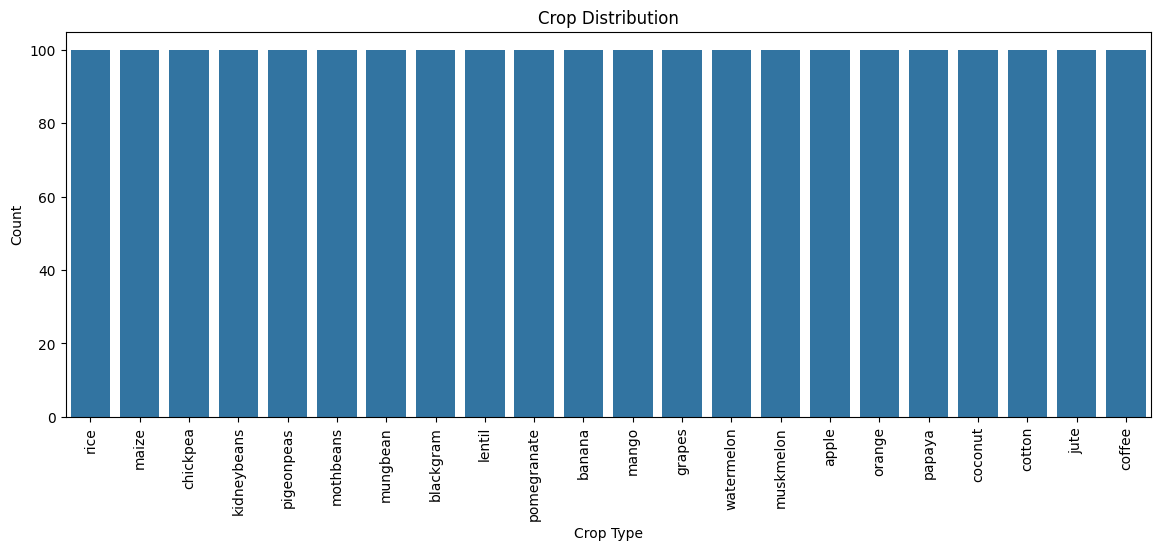

In [ ]:
plt.figure(figsize=(14,5))
sns.countplot(data=df, x='label', order=df['label'].value_counts().index)
plt.xticks(rotation=90)
plt.title("Crop Distribution")
plt.xlabel("Crop Type")
plt.ylabel("Count")
plt.show()

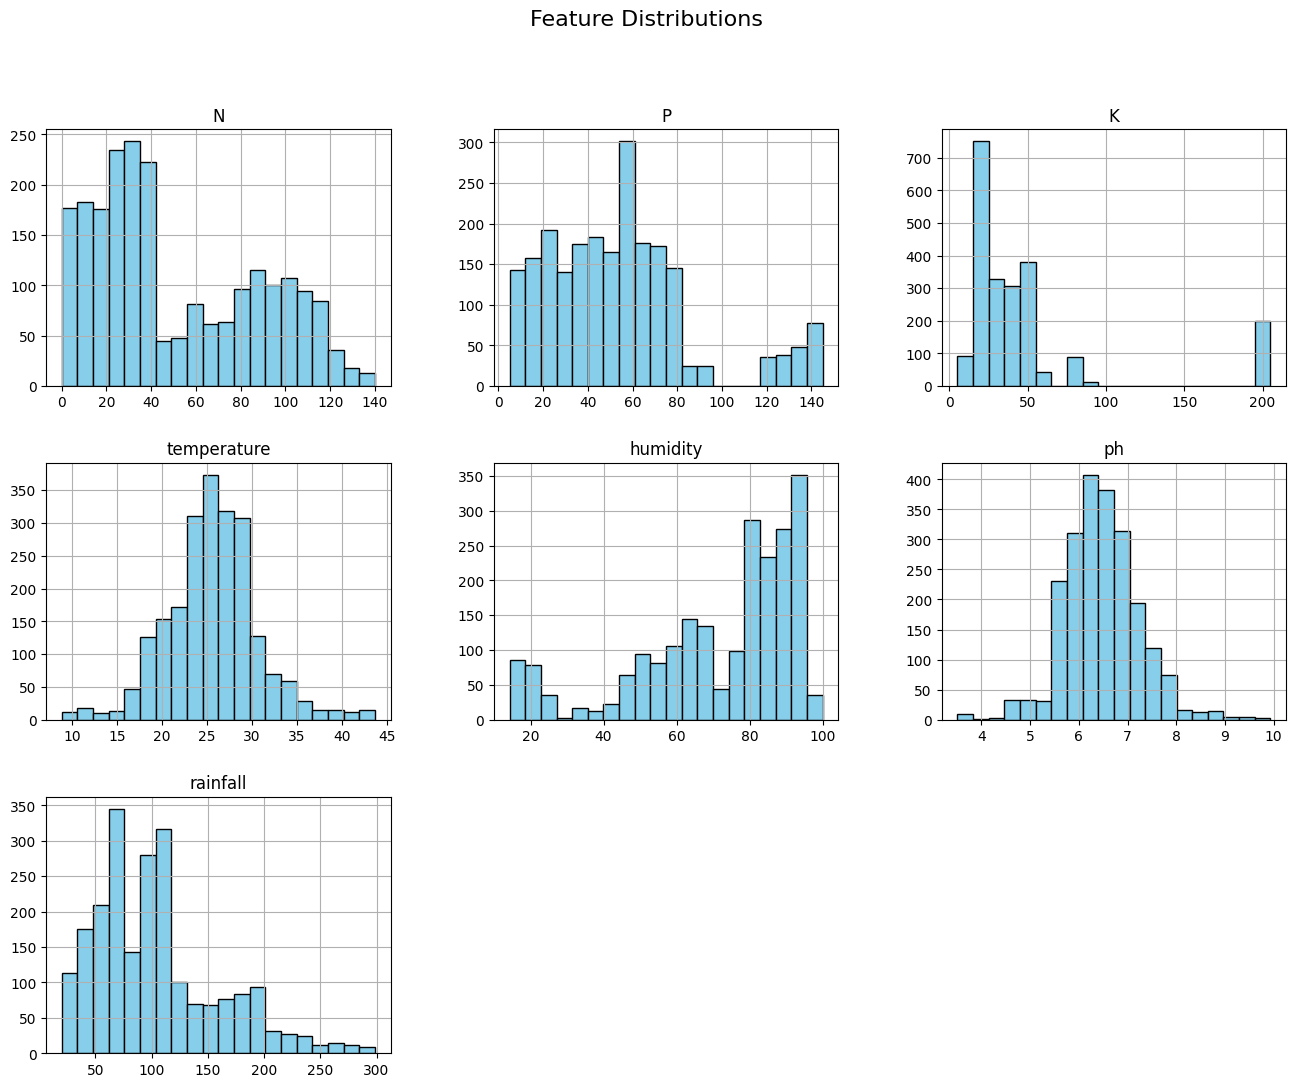

In [ ]:
df.drop('label', axis=1).hist(figsize=(16,12), bins=20, color='skyblue', edgecolor='black')
plt.suptitle("Feature Distributions", fontsize=16)
plt.show()

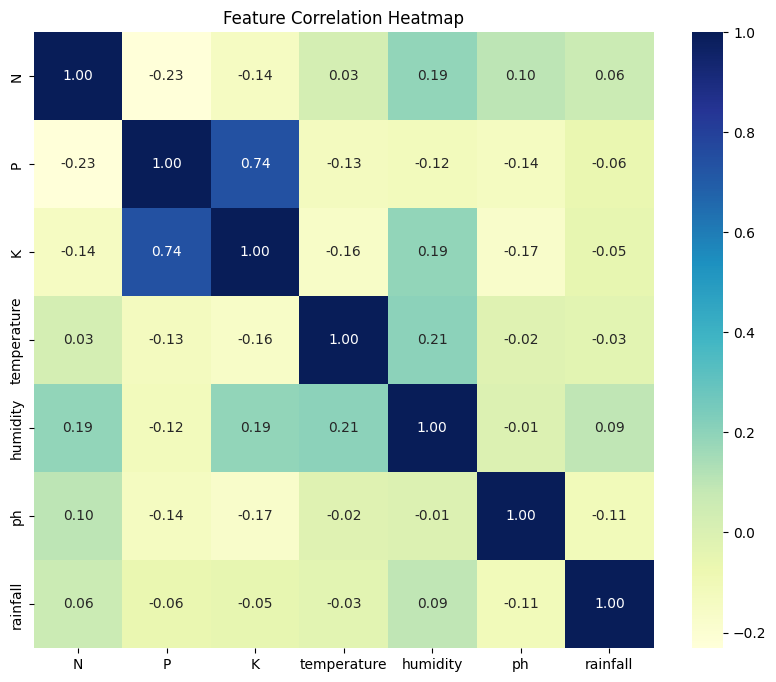

In [ ]:
plt.figure(figsize=(10,8))
sns.heatmap(df.drop('label', axis=1).corr(), annot=True, cmap="YlGnBu", fmt=".2f")
plt.title("Feature Correlation Heatmap")
plt.show()

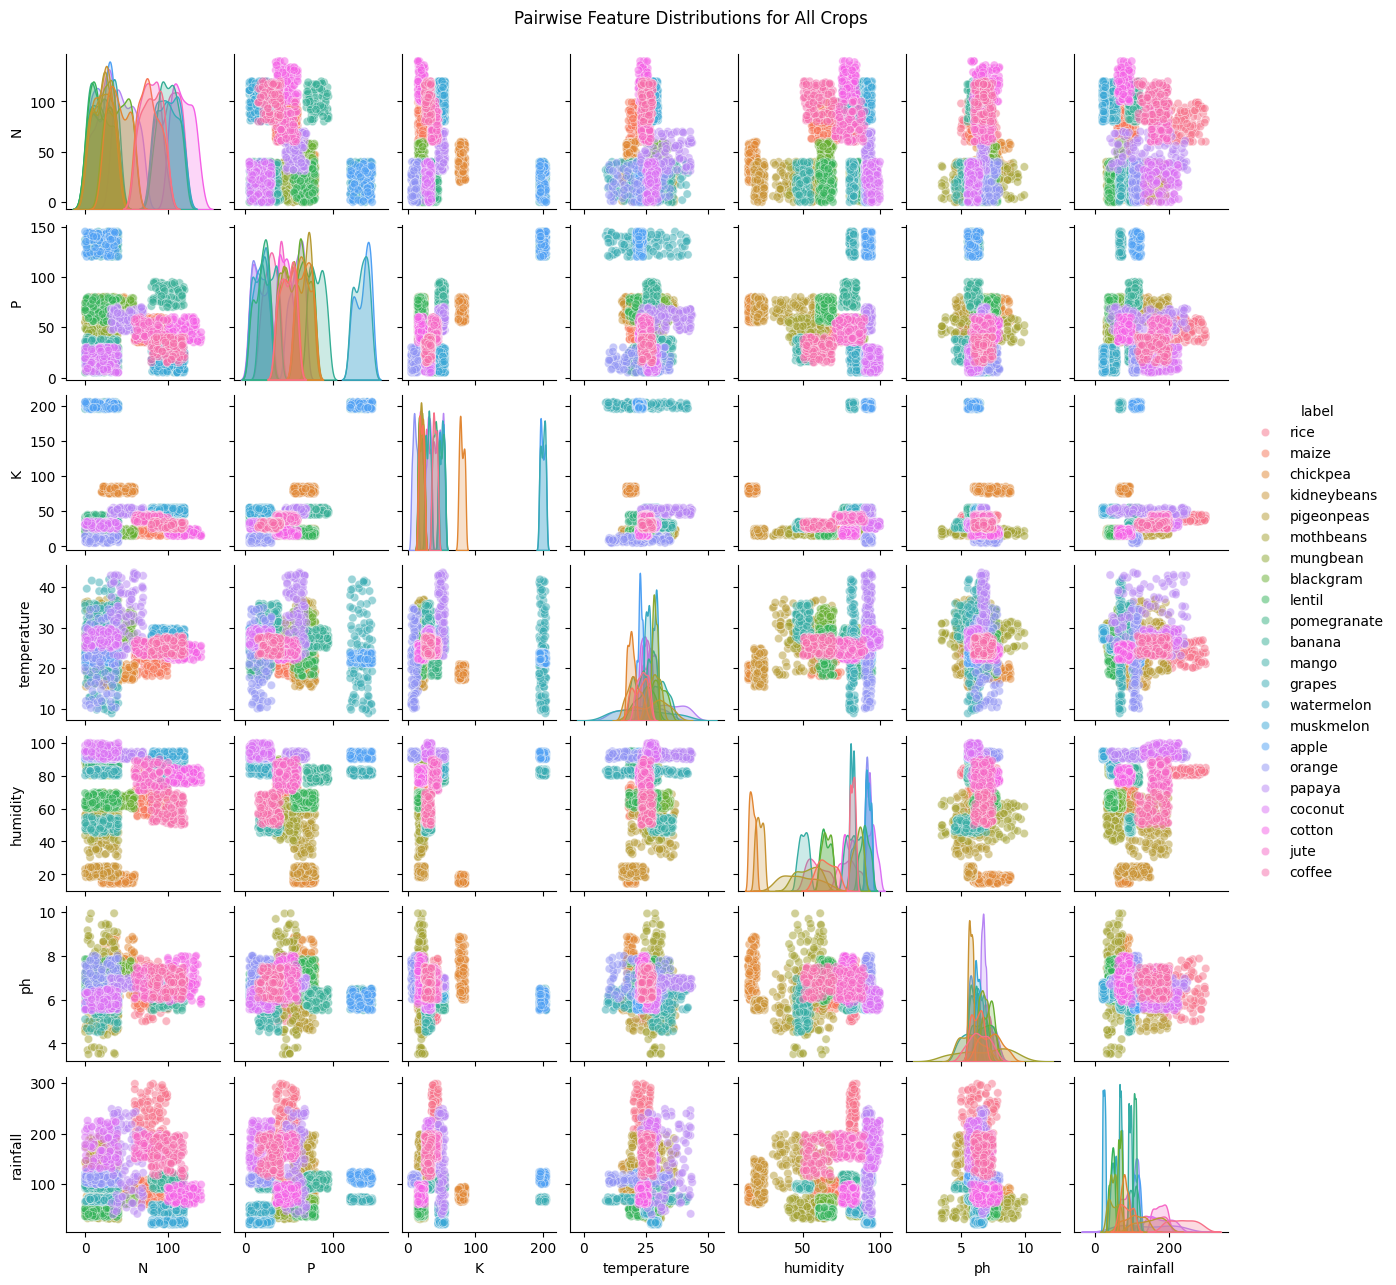

In [ ]:
import warnings
warnings.filterwarnings("ignore")
sns.pairplot(df, hue='label', plot_kws={'alpha': 0.5}, height=1.8)
plt.suptitle("Pairwise Feature Distributions for All Crops", y=1.02)
plt.show()

In [ ]:
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
import numpy as np


X = df.drop('label', axis=1)
y = df['label']


label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)


scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


X_reshaped = X_scaled.reshape((X_scaled.shape[0], 1, X_scaled.shape[1]))

print("X shape:", X_reshaped.shape)
print("y shape:", y_encoded.shape)

X shape: (2200, 1, 7)
y shape: (2200,)


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.utils import to_categorical
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

num_classes = len(np.unique(y_encoded))


model = Sequential()
model.add(LSTM(128, input_shape=(X_reshaped.shape[1], X_reshaped.shape[2]), return_sequences=False))
model.add(Dropout(0.3))
model.add(Dense(64, activation='relu'))
model.add(Dense(num_classes, activation='softmax'))  # multi-class classification
model.compile(loss='sparse_categorical_crossentropy', optimizer='adam', metrics=['accuracy'])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 128)            │        69,632 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 22)             │         1,430 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,318 (309.84 KB)

 Trainable params: 79,318 (309.84 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping


X_train, X_test, y_train, y_test = train_test_split(X_reshaped, y_encoded, test_size=0.2, random_state=42)


early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - accuracy: 0.0836 - loss: 3.0834 - val_accuracy: 0.2841 - val_loss: 3.0317
Epoch 2/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.2843 - loss: 2.9942 - val_accuracy: 0.3381 - val_loss: 2.8154
Epoch 3/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.3516 - loss: 2.6979 - val_accuracy: 0.4858 - val_loss: 2.3023
Epoch 4/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.4912 - loss: 2.1583 - val_accuracy: 0.6051 - val_loss: 1.6838
Epoch 5/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6182 - loss: 1.5605 - val_accuracy: 0.7500 - val_loss: 1.1878
Epoch 6/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7301 - loss: 1.1640 - val_accuracy: 0.8580 - val_loss: 0.8834
Epoch 7/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7681 - loss: 0.9048 - val_accuracy: 0.8807 - val_loss: 0.6967
Epoch 8/100
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8233 - loss: 0.7280 - val_accuracy: 0.8892 - 

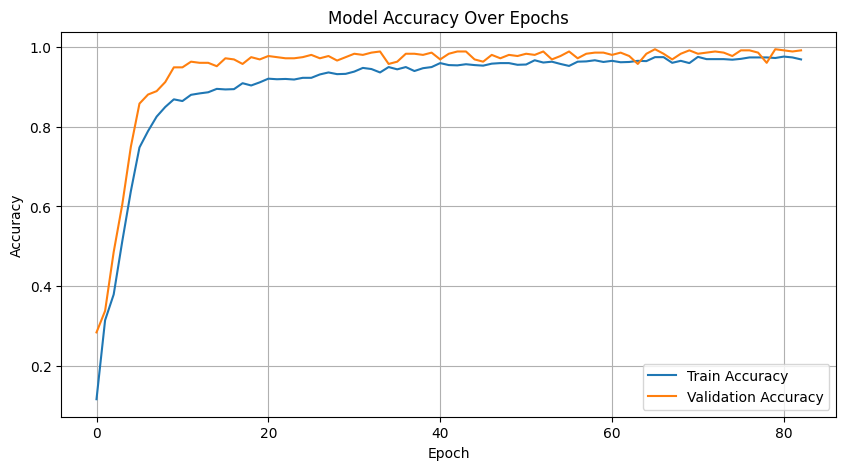

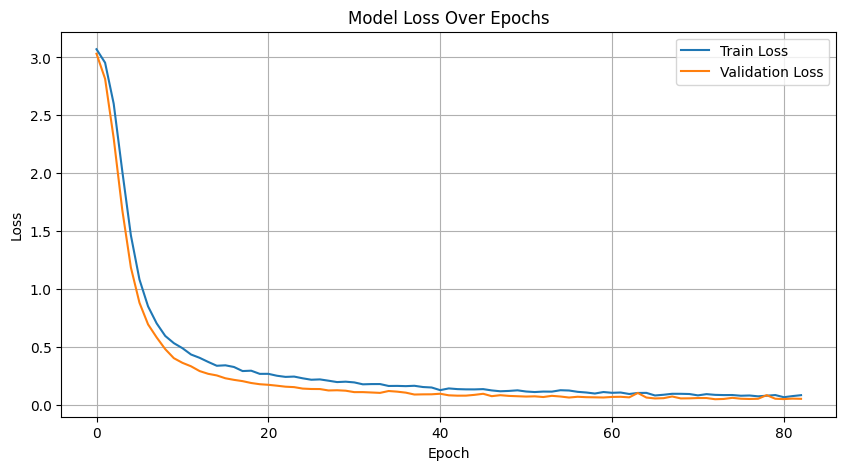

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()


plt.figure(figsize=(10,5))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Model Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score
import seaborn as sns
import numpy as np


y_pred_probs = model.predict(X_test)


y_pred = np.argmax(y_pred_probs, axis=1)


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=label_encoder.classes_))


f1 = f1_score(y_test, y_pred, average='macro')
print("Macro F1 Score:", round(f1, 4))

14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step
Classification Report:
              precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       0.95      0.95      0.95        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       0.94      1.00      0.97        17
      cotton       0.94      1.00      0.97        17
      grapes       1.00      1.00      1.00        14
        jute       0.88      0.91      0.89        23
 kidneybeans       0.95      1.00      0.98        20
      lentil       0.73      1.00      0.85        11
       maize       1.00      0.95      0.98        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.88      0.93        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange      

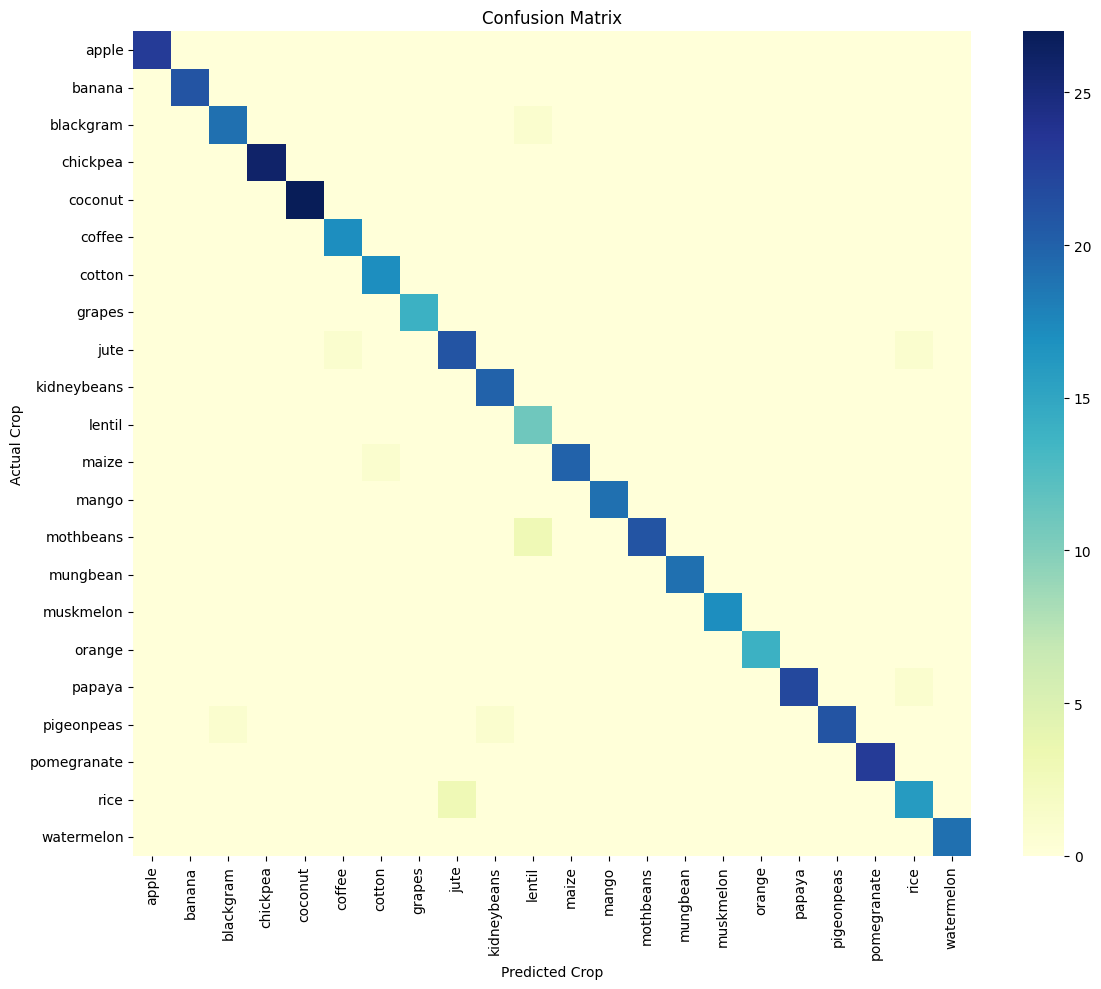

In [ ]:

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))
sns.heatmap(cm, annot=False, fmt='d', cmap='YlGnBu',
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Crop")
plt.ylabel("Actual Crop")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [ ]:
x_train.shape

(1760, 7)

In [ ]:
df.shape

(2200, 8)

In [ ]:
x_test.shape

(440, 7)

In [ ]:

idx = np.random.randint(0, X_test.shape[0])
sample = X_test[idx].reshape(1, 1, X_test.shape[2])
true_label = label_encoder.inverse_transform([y_test[idx]])[0]
pred_label = label_encoder.inverse_transform([np.argmax(model.predict(sample))])[0]

print(f"🌾 Actual Crop: {true_label}")
print(f"🤖 Predicted Crop: {pred_label}")


original_input = scaler.inverse_transform(X_test[idx].reshape(1, -1))[0]

columns = df.drop("label", axis=1).columns
for col, val in zip(columns, original_input):
    print(f"{col}: {val:.2f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
🌾 Actual Crop: coconut
🤖 Predicted Crop: coconut
N: 23.00
P: 21.00
K: 26.00
temperature: 26.45
humidity: 93.45
ph: 5.90
rainfall: 149.22


In [ ]:
model.save("crop_recommendation_lstm_model.h5")
print("✅ Model saved as crop_recommendation_lstm_model.h5")

✅ Model saved as crop_recommendation_lstm_model.h5


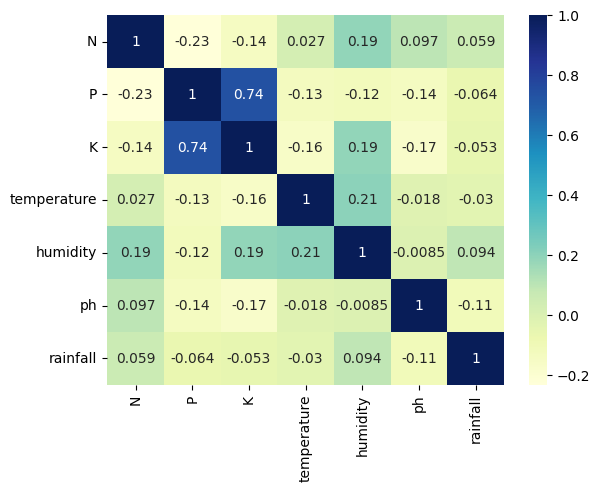

In [ ]:
df_new = df.drop(columns = "label")

sns.heatmap(df_new.corr(), annot=True, cmap="YlGnBu")
plt.show()

In [ ]:
for column in df_new.columns.tolist():
    print(f"\nlabel with {column}\n")
    display(df.groupby("label")[column].describe().reset_index())


label with N



,label,count,mean,std,min,25%,50%,75%,max
0,apple,100.0,20.80,11.863704,0.0,10.00,24.0,30.00,40.0
1,banana,100.0,100.23,11.107241,80.0,92.00,100.5,108.25,120.0
2,blackgram,100.0,40.02,12.664258,20.0,28.75,41.0,52.00,60.0
3,chickpea,100.0,40.09,12.150649,20.0,30.00,39.0,52.00,60.0
4,coconut,100.0,21.98,11.761931,0.0,13.75,24.0,31.00,40.0
5,coffee,100.0,101.20,12.345203,80.0,89.00,103.0,112.00,120.0
6,cotton,100.0,117.77,11.628817,100.0,107.75,117.0,127.50,140.0
7,grapes,100.0,23.18,12.466829,0.0,11.75,24.0,35.00,40.0
8,jute,100.0,78.40,10.968274,60.0,70.00,78.0,88.25,100.0
9,kidneybeans,100.0,20.75,10.834266,0.0,11.75,22.0,28.00,40.0



label with P



,label,count,mean,std,min,25%,50%,75%,max
0,apple,100.0,134.22,8.139665,120.0,126.75,136.5,141.00,145.0
1,banana,100.0,82.01,7.690339,70.0,75.00,81.0,88.00,95.0
2,blackgram,100.0,67.47,7.151259,55.0,62.00,67.0,74.00,80.0
3,chickpea,100.0,67.79,7.498545,55.0,61.00,68.0,74.00,80.0
4,coconut,100.0,16.93,8.357244,5.0,9.75,15.5,24.25,30.0
5,coffee,100.0,28.74,7.276113,15.0,23.00,29.0,34.25,40.0
6,cotton,100.0,46.24,7.348634,35.0,40.00,46.0,52.00,60.0
7,grapes,100.0,132.53,7.619029,120.0,125.75,133.0,139.00,145.0
8,jute,100.0,46.86,7.195706,35.0,41.00,46.0,53.25,60.0
9,kidneybeans,100.0,67.54,7.571104,55.0,61.00,67.0,74.00,80.0



label with K



...

,label,count,mean,std,min,25%,50%,75%,max
0,apple,100.0,92.333383,1.458551,90.025751,90.970127,92.416541,93.509252,94.920481
1,banana,100.0,80.358123,2.805481,75.031933,78.062229,80.223599,82.960240,84.978492
2,blackgram,100.0,65.118426,2.798326,60.065349,63.040532,65.026723,67.741171,69.961000
3,chickpea,100.0,16.860439,1.711979,14.258040,15.392700,16.658634,18.265986,19.969789
4,coconut,100.0,94.844272,2.686329,90.017345,92.544995,94.960581,96.759684,99.981876
5,coffee,100.0,58.869846,5.838566,50.045570,53.814433,57.648083,63.579586,69.948073
6,cotton,100.0,79.843474,3.050955,75.005393,77.035008,80.010893,82.364946,84.876690
7,grapes,100.0,81.875228,1.177111,80.016394,80.859457,81.724647,82.899224,83.983517
8,jute,100.0,79.639864,5.507798,70.882596,74.588266,79.469205,83.232826,89.891065
9,kidneybeans,100.0,21.605357,2.167323,18.092240,19.735894,21.348735,23.357184,24.969699



label with ph



,label,count,mean,std,min,25%,50%,75%,max
0,apple,100.0,5.929663,0.268932,5.514253,5.705800,5.885818,6.135616,6.499227
1,banana,100.0,5.983893,0.270650,5.505394,5.740712,5.994462,6.211092,6.490074
2,blackgram,100.0,7.133952,0.372533,6.500145,6.812736,7.165240,7.419390,7.775306
3,chickpea,100.0,7.336957,0.801127,5.988993,6.603967,7.356537,7.861625,8.868741
4,coconut,100.0,5.976562,0.287632,5.501580,5.731053,5.990709,6.209201,6.470466
5,coffee,100.0,6.790308,0.417132,6.020947,6.429728,6.798626,7.132105,7.493192
6,cotton,100.0,6.912675,0.627170,5.801048,6.364399,6.840957,7.426792,7.994680
7,grapes,100.0,6.025937,0.298265,5.510925,5.776854,6.001785,6.313711,6.499605
8,jute,100.0,6.732778,0.446349,6.002525,6.348010,6.711500,7.126526,7.488014
9,kidneybeans,100.0,5.749411,0.145220,5.502999,5.624995,5.745283,5.868351,5.998125



label with rainfall



,label,count,mean,std,min,25%,50%,75%,max
0,apple,100.0,112.654779,7.102985,100.117344,106.070135,112.979230,118.449546,124.983162
1,banana,100.0,104.626980,9.398150,90.109781,96.471109,105.007750,112.092171,119.847970
2,blackgram,100.0,67.884151,4.184186,60.417903,64.049755,68.293539,71.397924,74.915595
3,chickpea,100.0,80.058977,7.944350,65.113656,73.610409,79.692282,85.824482,94.781896
4,coconut,100.0,175.686646,29.472333,131.090008,149.126478,171.999922,202.351490,225.632366
5,coffee,100.0,158.066295,25.695086,115.156401,136.011746,157.770963,181.472018,199.473564
6,cotton,100.0,80.398043,11.231812,60.653817,70.894298,80.237095,90.418270,99.931008
7,grapes,100.0,69.611829,2.951759,65.010953,66.836826,69.536186,71.609366,74.915062
8,jute,100.0,174.792798,15.078367,150.235524,161.090683,175.590814,187.641532,199.836291
9,kidneybeans,100.0,105.919778,26.111384,60.275525,85.824741,107.399392,129.399964,149.744103


N: 0.5097213691539147


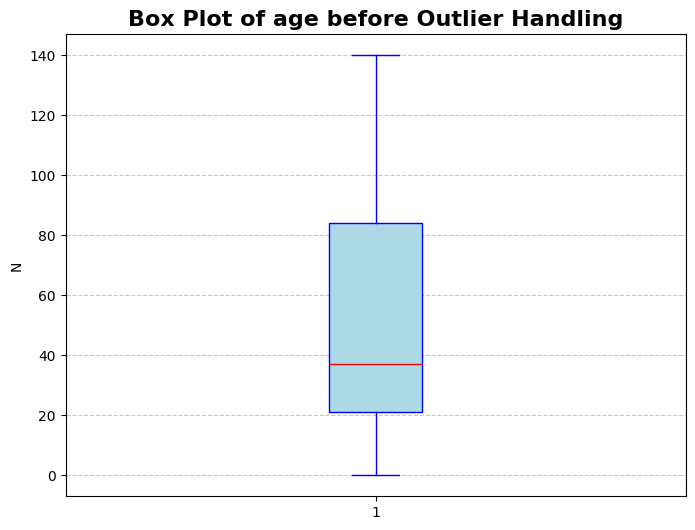

P: 1.0107725431372674


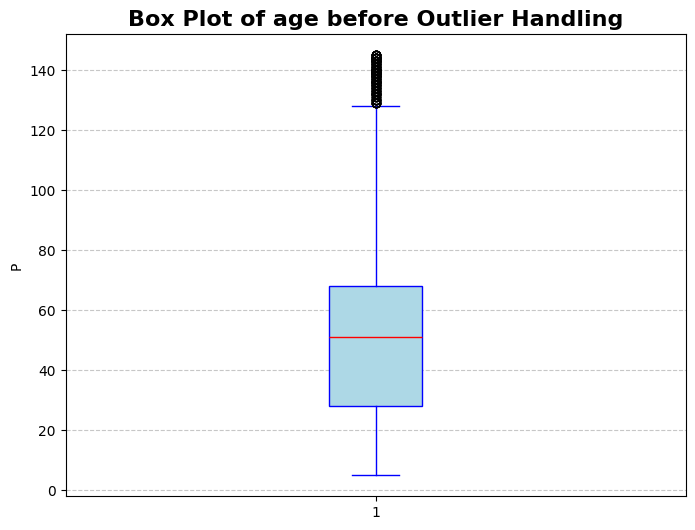

K: 2.3751672388547


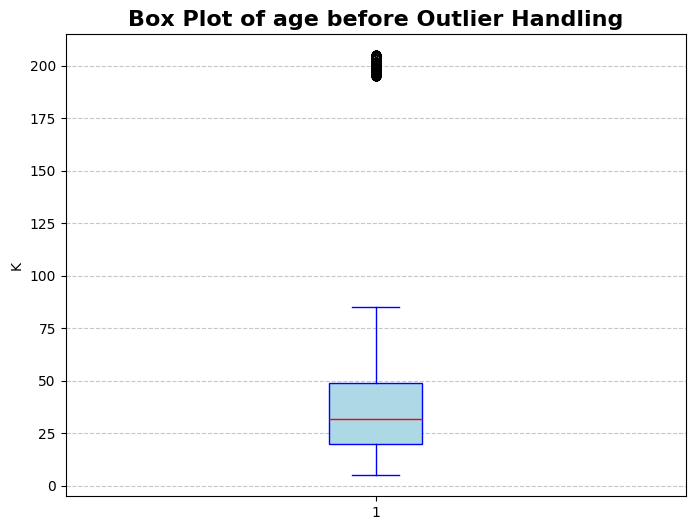

temperature: 0.18493273421137887


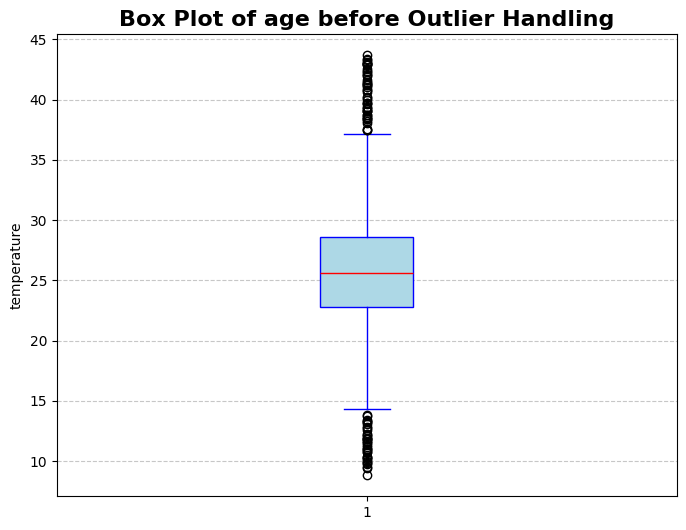

humidity: -1.0917079195808679


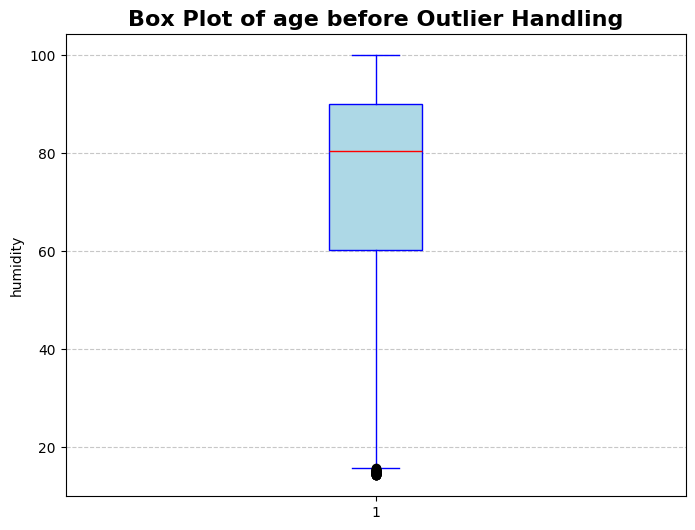

ph: 0.2839294375729441


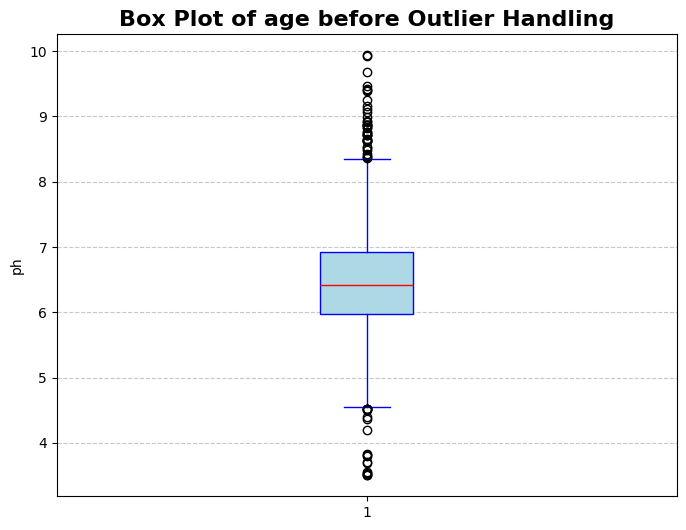

rainfall: 0.9657563536272812


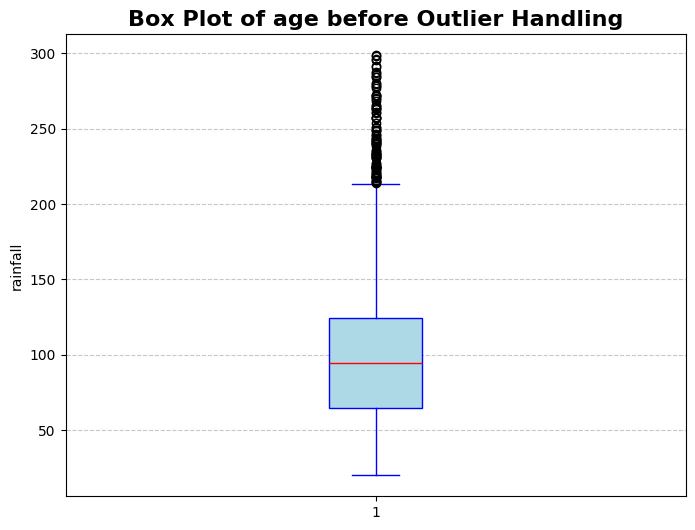

In [ ]:
for column in df_new.columns.tolist():
    print(f"{column}: {df[column].skew()}")
    plt.figure(figsize = (8, 6), dpi = 100, facecolor = "white", edgecolor = "black")
    plt.boxplot(
        df[column],
        vert = True,
        patch_artist = True,
        boxprops=dict(facecolor="lightblue", color="blue"),
        medianprops=dict(color="red"),
        whiskerprops=dict(color="blue"),
        capprops=dict(color="blue")
    )
    plt.title("Box Plot of age before Outlier Handling", fontsize = 16, fontweight = "bold", color = "black")
    plt.ylabel(column)
    plt.grid(axis = "y", linestyle = "--", alpha = 0.7)
    plt.show()

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score

model = LogisticRegression()


kf = KFold(n_splits=5, shuffle=True, random_state=42)
X = df.drop(columns = "label")
y = df["label"]


scores = cross_val_score(model, X, y, cv=kf, scoring="accuracy")

print("Cross-validation accuracies:", scores)
print("Mean Accuracy:", scores.mean())

Cross-validation accuracies: [0.94545455 0.96363636 0.96363636 0.95681818 0.96363636]
Mean Accuracy: 0.9586363636363637


In [ ]:
print("Std Dev:", scores.std())


Std Dev: 0.007100226978096962


In [ ]:
x_train, x_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42, stratify = y, shuffle = True)

In [ ]:
model_train = LogisticRegression()

In [ ]:
model_train.fit(x_train, y_train)

LogisticRegression()

In [ ]:
Y_pred = model_train.predict(x_test)

In [ ]:
x=df.drop(["label"],axis=1)
y=df["label"]

In [ ]:
from sklearn.preprocessing import StandardScaler
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
ss=StandardScaler()
x_train=ss.fit_transform(x_train)
x_test=ss.transform(x_test)

In [ ]:
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(n_estimators=100)
model.fit(x_train,y_train)

RandomForestClassifier()

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score, roc_auc_score

y_pred = model.predict(x_test)
y_pred_proba = model.predict_proba(x_test)

accuracy = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average='macro')
precision = precision_score(y_test, y_pred, average='macro')
recall = recall_score(y_test, y_pred, average='macro')

roc_auc = roc_auc_score(y_test, y_pred_proba, multi_class='ovr', average='macro')
print(f"Accuracy: {accuracy}")
print(f"F1 Score: {f1}")
print(f"Precision: {precision}")
print(f"Recall: {recall}")
print(f"ROC AUC: {roc_auc}")

Accuracy: 0.9931818181818182
F1 Score: 0.9926374055074331
Precision: 0.9925757575757576
Recall: 0.9933213716108454
ROC AUC: 0.9999284621149108


In [ ]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

       apple       1.00      1.00      1.00        23
      banana       1.00      1.00      1.00        21
   blackgram       1.00      1.00      1.00        20
    chickpea       1.00      1.00      1.00        26
     coconut       1.00      1.00      1.00        27
      coffee       1.00      1.00      1.00        17
      cotton       1.00      1.00      1.00        17
      grapes       1.00      1.00      1.00        14
        jute       0.92      1.00      0.96        23
 kidneybeans       1.00      1.00      1.00        20
      lentil       0.92      1.00      0.96        11
       maize       1.00      1.00      1.00        21
       mango       1.00      1.00      1.00        19
   mothbeans       1.00      0.96      0.98        24
    mungbean       1.00      1.00      1.00        19
   muskmelon       1.00      1.00      1.00        17
      orange       1.00      1.00      1.00        14
  

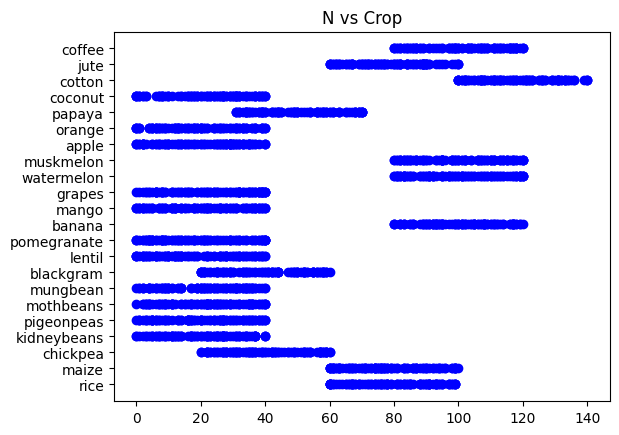

In [ ]:
plt.scatter('N','label',data=df,c='blue') # Required Nitrogen Vs Crop
plt.title('N vs Crop')
plt.show()

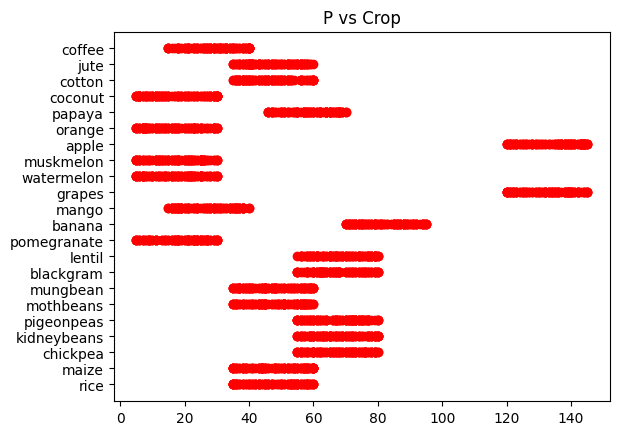

In [ ]:
plt.scatter('P','label',data=df,c='red') # Required Phosphorus Vs Crop
plt.title('P vs Crop')
plt.show()

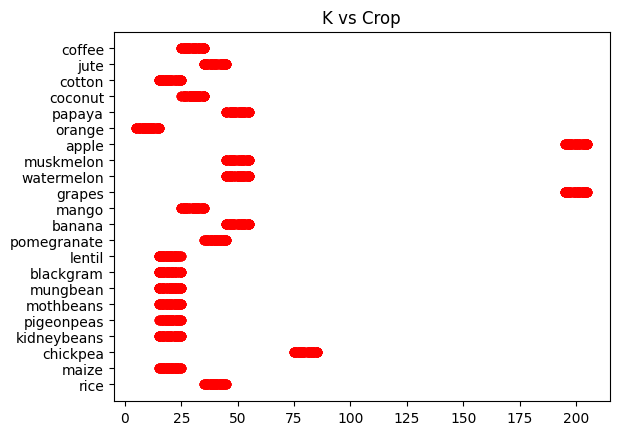

In [ ]:
plt.scatter('K','label',data=df,c='red') # Required Potesium Vs Crop
plt.title('K vs Crop')
plt.show()

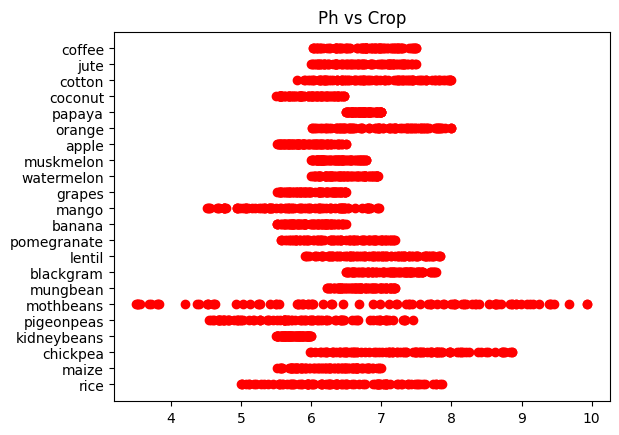

In [ ]:
plt.scatter('ph','label',data=df,c='red') # Required ph Vs Crop
plt.title('Ph vs Crop')
plt.show()

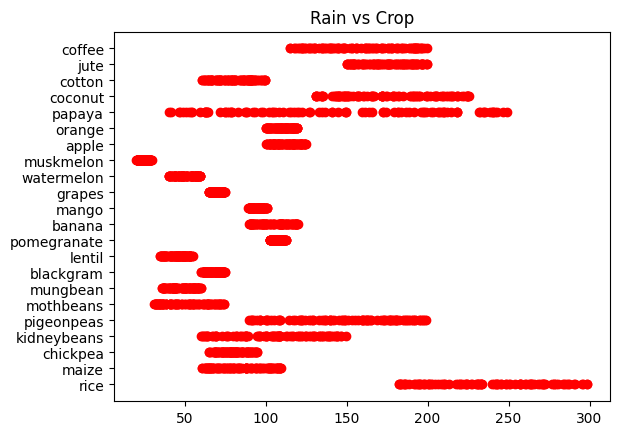

In [ ]:
plt.scatter('rainfall','label',data=df,c='red') # Required rain Vs Crop
plt.title('Rain vs Crop')
plt.show()